# Netflix Movies & TV Shows - Data Analysis

**Tools:** Python | Pandas | NumPy | Matplotlib
**Dataset:** 8,807 Netflix Titles
**By:** Eman Fatima

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")

## Data Exploration

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## Missing values analysis

In [7]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Data Cleaning

In [8]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")
df["duration"] = df["duration"].fillna("Unknown")
df = df.dropna(subset =["date_added"])
df.isnull().sum()
df.shape

(8797, 12)

## date conversion

In [9]:
df["date_added"] = pd.to_datetime(df["date_added"], errors = "coerce")
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month
df[["date_added", "year_added", "month_added"]].head()


,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


## Data Analysis & Visualization

### Movies vs TV Shows Distribution

In [10]:
df["type"].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

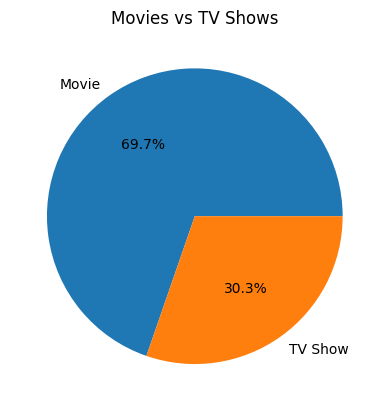

In [11]:
df["type"].value_counts().plot(kind = "pie", autopct = "%1.1f%%")
plt.title("Movies vs TV Shows")
plt.show()


### Top 10 Countries

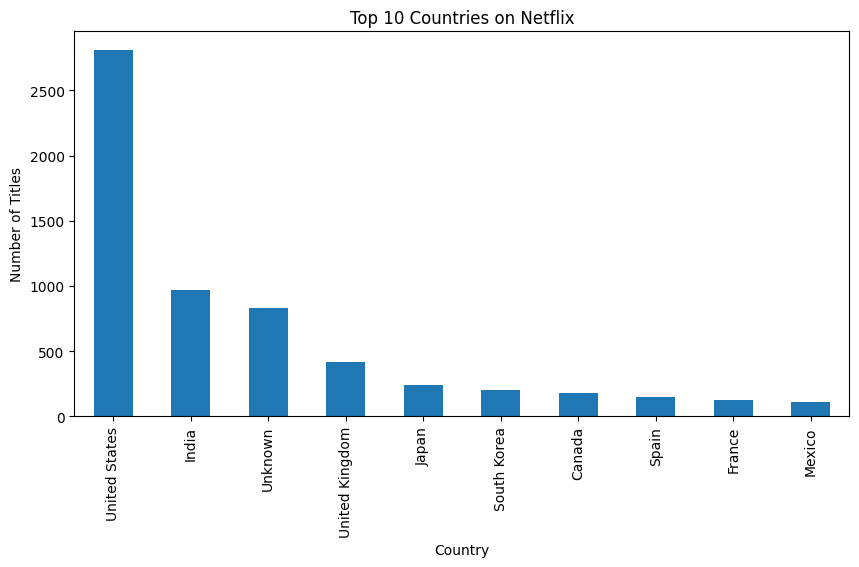

In [12]:
df["country"].value_counts().head(10).plot(kind = "bar", figsize = (10,5))
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

## Key Findings & Conclusions

In [13]:
movies = df[df['type'] == 'Movie'].shape[0]
shows = df[df['type'] == 'TV Show'].shape[0]
top_country = df[df['country'] != 'Unknown']['country'].value_counts().index[0]
peak_year = df.groupby('year_added')['title'].count().idxmax()

print("=" * 40)
print("  KEY FINDINGS")
print("=" * 40)
print(f"  Total Titles  : {len(df)}")
print(f"  Total Movies  : {movies}")
print(f"  Total TV Shows: {shows}")
print(f"  Top Country   : {top_country}")
print(f"  Peak Year     : {int(peak_year)}")
print("=" * 40)

  KEY FINDINGS
  Total Titles  : 8797
  Total Movies  : 6131
  Total TV Shows: 2666
  Top Country   : United States
  Peak Year     : 2019
